# Churn Model Analysis: Baseline Review and V2 Design

**Purpose**: Audit the Phase 6 churn baseline, expose the structural and feature-level limitations using the actual data, and design a V2 grounded in evidence — not in generic ML best practice.

**Scope**: `mart_customer_features` (50,000 customers), label `churn_flag_90d` (17.1% prevalence).

**Sequence**:
1. Methodology — what churn means here, what the baseline did
2. Population structure — who should be in the training set
3. Feature landscape — what currently has signal, what doesn't
4. Recency leakage audit — does `recency_days` proxy the label?
5. Null interpretation — what nulls actually mean
6. Baseline review — RF vs LogReg, PR curve, threshold trade-offs
7. Feature engineering proposal — three new features with evidence
8. Model and split strategy for V2
9. V2 design summary — decision table and what changes

## 0  Methodology

### What "churn" means in this dataset

`churn_flag_90d = 1` if a customer has not placed an order in the last 90 days. This is a **proxy label**, not a contract cancellation. Two consequences flow from this definition:

- **Customers who never purchased cannot churn** — they have no `recency_days` to compare against the 90-day window. They are mechanically labelled `0`.
- **Recency is the label.** Any feature derived directly from `recency_days` risks being a tautology. We will audit this in §3.

### What the Phase 6 baseline did

| Choice | Value |
|---|---|
| Models | Logistic Regression (balanced), Random Forest (balanced subsample) |
| Split | Stratified random 80/20 |
| Approved features | 34 (after leakage audit) |
| Null handling | Implicit via sklearn `SimpleImputer` in pipeline |
| Best model | RF — ROC AUC 0.866, PR AUC 0.597 |
| Operating thresholds | 0.35 (max-F1), 0.70 (precision-floor 0.70) |

### What this notebook will do

1. Compute the actual churn rate within every approved feature on this data
2. Identify features with high heterogeneity that the baseline does not use or derive
3. Test each candidate engineered feature for leakage before proposing it for V2
4. Document the decision for each V2 change against an evidence row from this dataset

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from src.data.mart_loaders import load_mart

# ── Plot styling ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
})

PALETTE = {
    'churn': '#C0392B',
    'retain': '#2E86C1',
    'neutral': '#7F8C8D',
    'highlight': '#E67E22',
    'good': '#27AE60',
    'bad': '#C0392B',
}

OUTPUTS = pathlib.Path('../outputs')

mart = load_mart('mart_customer_features')
print(f'Mart loaded:  {mart.shape[0]:,} customers  ×  {mart.shape[1]} columns')
print(f'Churn rate:   {mart["churn_flag_90d"].mean():.2%}')
print(f'Date range:   signup_date  {mart["signup_date"].min().date()}  →  {mart["signup_date"].max().date()}')

Mart loaded:  50,000 customers  ×  40 columns
Churn rate:   17.12%
Date range:   signup_date  2022-07-10  →  2025-12-21


## 1  Population Structure

Before discussing features or models, we need to ask a more basic question: **who is in the training set, and is that the right population to model?**

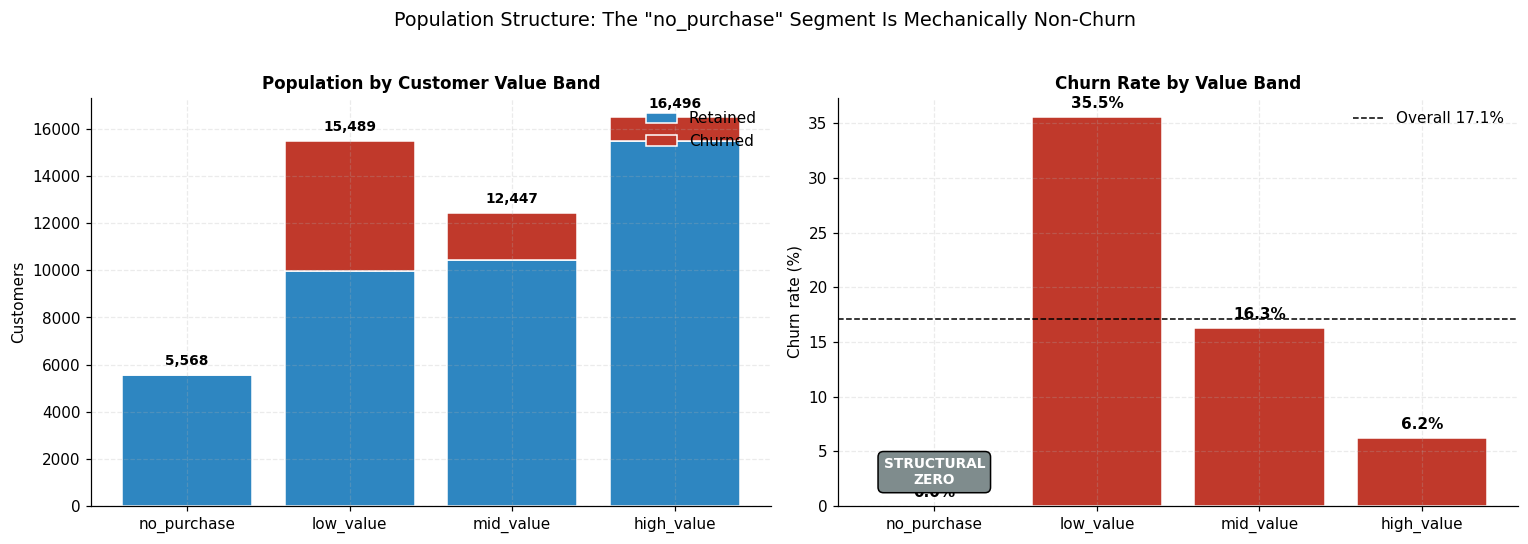


no_purchase segment:  5,568 customers  (11.1% of mart)
  churn_flag_90d = 1:   0  (cannot churn — never purchased)
  recency_days nulls:   5,568
  total_orders nulls:   5,568


In [2]:
# ── Population breakdown by customer_value_band and churn ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: population counts by value band, stacked by churn
band_order = ['no_purchase', 'low_value', 'mid_value', 'high_value']
ct = pd.crosstab(mart['customer_value_band'], mart['churn_flag_90d']).reindex(band_order)
ct.columns = ['retained', 'churned']

ax = axes[0]
bars_r = ax.bar(ct.index, ct['retained'], color=PALETTE['retain'], label='Retained', edgecolor='white')
bars_c = ax.bar(ct.index, ct['churned'], bottom=ct['retained'], color=PALETTE['churn'], label='Churned', edgecolor='white')
ax.set_ylabel('Customers')
ax.set_title('Population by Customer Value Band')
ax.legend(loc='upper right', frameon=False)
for i, band in enumerate(ct.index):
    total = ct.loc[band].sum()
    ax.text(i, total + 400, f'{total:,}', ha='center', fontsize=9, fontweight='bold')

# Right: churn rate per band with annotation
ax = axes[1]
churn_rate = ct['churned'] / ct.sum(axis=1)
colors = [PALETTE['neutral'] if b == 'no_purchase' else PALETTE['churn'] for b in ct.index]
bars = ax.bar(churn_rate.index, churn_rate.values * 100, color=colors, edgecolor='white')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn Rate by Value Band')
ax.axhline(mart['churn_flag_90d'].mean() * 100, color='black', linestyle='--', lw=1, label=f'Overall {mart["churn_flag_90d"].mean():.1%}')
ax.legend(frameon=False)
for bar, rate in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8, f'{rate:.1%}',
            ha='center', fontsize=10, fontweight='bold')

# Highlight no_purchase
ax.text(0, 2, 'STRUCTURAL\nZERO', ha='center', fontsize=9, color='white',
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['neutral']))

plt.suptitle('Population Structure: The "no_purchase" Segment Is Mechanically Non-Churn', fontsize=12.5, y=1.02)
plt.tight_layout()
plt.show()

# Print the structural finding
np_seg = mart[mart['customer_value_band'] == 'no_purchase']
print(f'\nno_purchase segment:  {len(np_seg):,} customers  ({len(np_seg)/len(mart):.1%} of mart)')
print(f'  churn_flag_90d = 1:   {np_seg["churn_flag_90d"].sum()}  (cannot churn — never purchased)')
print(f'  recency_days nulls:   {np_seg["recency_days"].isna().sum():,}')
print(f'  total_orders nulls:   {np_seg["total_orders"].isna().sum():,}')

**Finding 1 — `no_purchase` is a structural zero**

5,568 customers (11.1% of the mart) have `customer_value_band = no_purchase` and `churn_flag_90d = 0` for every single row. They have never placed an order, so by label definition they cannot have been inactive for 90 days *since their last order*. They are mechanically labelled non-churn.

**Implication for V2**: Including these rows in training tells the model that "all-feature-nulls + segment_seed in {one_time, at_risk, ...} → non-churn", which is true *only because of the label definition*, not because of any retention signal. A separate "first purchase" model is the right instrument for this population.

**Decision for V2**: Train churn model on `customer_value_band != no_purchase` only (44,432 rows). Keep no_purchase customers in scoring infrastructure but route them to a different (out-of-scope) workflow.

## 2  Feature Landscape — What Already Has Signal

We restrict to the active population (`customer_value_band != no_purchase`, n=44,432) for the rest of the analysis. We measure each feature by its **churn-rate spread across quintiles or categories** — the difference between the highest and lowest bucket. A feature with no spread cannot help the model rank customers by churn risk, regardless of model capacity.

In [3]:
# ── Active population (drop no_purchase for analysis) ──────────────────────
active = mart[mart['customer_value_band'] != 'no_purchase'].copy()
print(f'Active population:  {len(active):,}  ({len(active)/len(mart):.1%} of mart)')
print(f'Churn rate:         {active["churn_flag_90d"].mean():.2%}')

# ── Helper: churn rate spread across a feature's bins ──────────────────────
def churn_spread_numeric(df, col, n=5):
    s = df[[col, 'churn_flag_90d']].dropna(subset=[col])
    if s[col].nunique() < n:
        return None
    s = s.copy()
    s['_bin'] = pd.qcut(s[col], q=n, duplicates='drop')
    rates = s.groupby('_bin', observed=True)['churn_flag_90d'].mean()
    return float(rates.max() - rates.min())

def churn_spread_categorical(df, col):
    s = df[[col, 'churn_flag_90d']].dropna(subset=[col])
    rates = s.groupby(col)['churn_flag_90d'].mean()
    if len(rates) < 2:
        return None
    return float(rates.max() - rates.min())

approved = pd.read_csv(OUTPUTS / 'phase6_churn_approved_features.csv')['feature'].tolist()

rows = []
for feat in approved:
    if feat not in active.columns:
        continue
    if active[feat].dtype == object or active[feat].nunique() < 12:
        spread = churn_spread_categorical(active, feat)
        kind = 'categorical'
    else:
        spread = churn_spread_numeric(active, feat)
        kind = 'numeric'
    if spread is not None:
        rows.append({'feature': feat, 'kind': kind, 'churn_spread_pp': round(spread * 100, 2)})

signal_df = pd.DataFrame(rows).sort_values('churn_spread_pp', ascending=True)
print(f'\nApproved features evaluated: {len(signal_df)}')

Active population:  44,432  (88.9% of mart)
Churn rate:         19.27%

Approved features evaluated: 34


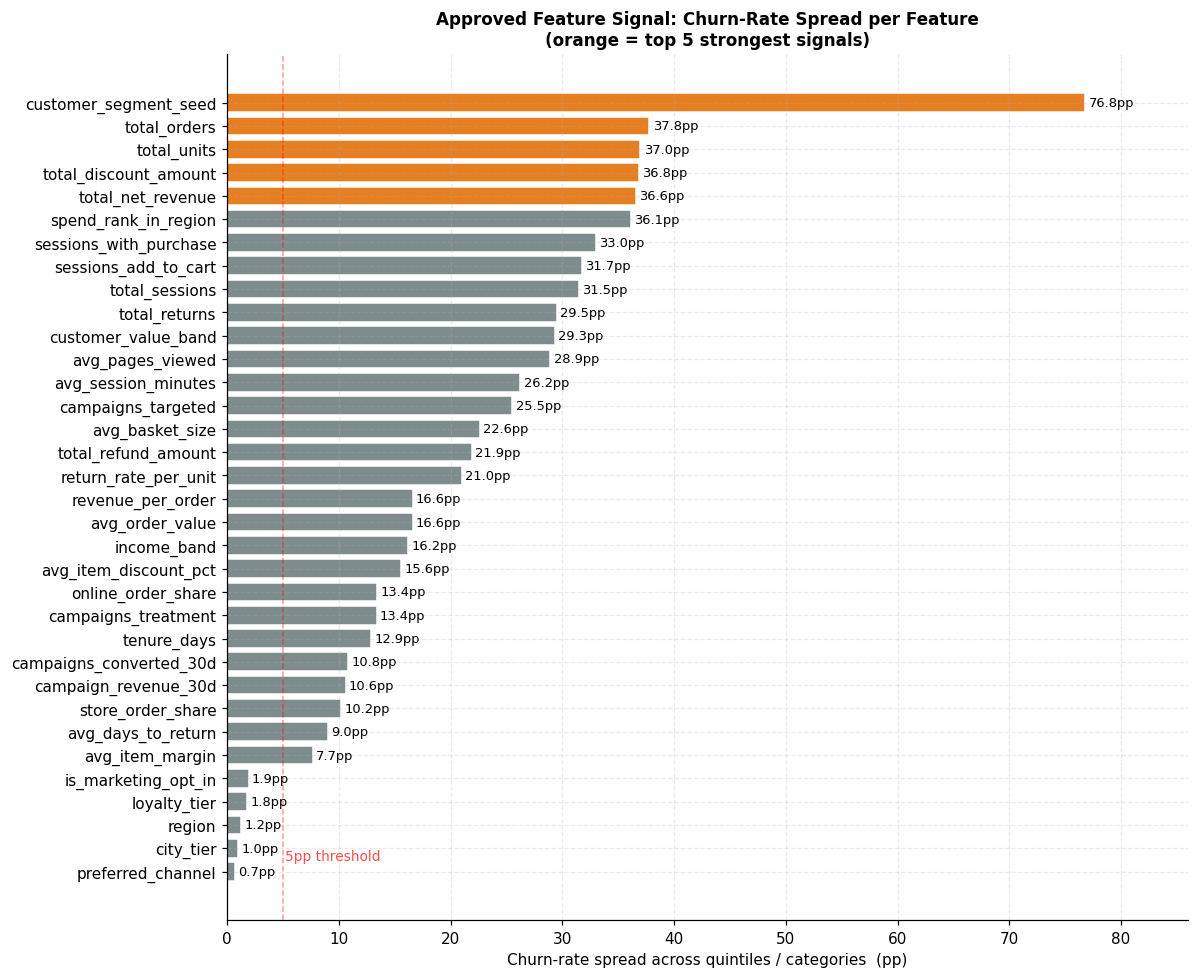


Top 5 features by spread:
              feature        kind  churn_spread_pp
customer_segment_seed categorical            76.78
         total_orders     numeric            37.79
          total_units     numeric            36.99
total_discount_amount     numeric            36.83
    total_net_revenue     numeric            36.58

Bottom 5 (weak signal):
            feature        kind  churn_spread_pp
  preferred_channel categorical             0.68
          city_tier categorical             0.96
             region categorical             1.21
       loyalty_tier categorical             1.80
is_marketing_opt_in categorical             1.91


In [4]:
# ── Visualise: churn-rate spread across all approved features ──────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Highlight the top 5 strongest signals
top_n = 5
colors = ['#7F8C8D'] * len(signal_df)
for i, (_, row) in enumerate(signal_df.iterrows()):
    if row['churn_spread_pp'] >= signal_df['churn_spread_pp'].nlargest(top_n).min():
        colors[i] = PALETTE['highlight']

bars = ax.barh(signal_df['feature'], signal_df['churn_spread_pp'], color=colors, edgecolor='white')
ax.set_xlabel('Churn-rate spread across quintiles / categories  (pp)')
ax.set_title('Approved Feature Signal: Churn-Rate Spread per Feature\n(orange = top 5 strongest signals)')
for i, (_, row) in enumerate(signal_df.iterrows()):
    ax.text(row['churn_spread_pp'] + 0.3, i, f'{row["churn_spread_pp"]:.1f}pp',
            va='center', fontsize=8.5)
ax.set_xlim(0, signal_df['churn_spread_pp'].max() * 1.12)
ax.axvline(5, color='red', linestyle='--', alpha=0.4, lw=1)
ax.text(5.2, 0.5, '5pp threshold', color='red', fontsize=9, alpha=0.7)
plt.tight_layout()
plt.show()

# Tabular top/bottom
print('\nTop 5 features by spread:')
print(signal_df.nlargest(5, 'churn_spread_pp').to_string(index=False))
print('\nBottom 5 (weak signal):')
print(signal_df.nsmallest(5, 'churn_spread_pp').to_string(index=False))

**Finding 2 — feature signal is concentrated, with five low-signal categoricals**

`customer_segment_seed` (77pp spread) dominates because `at_risk` (44%) vs `high_value` (5%) almost perfectly partition the population. The next tier (volume features: `total_orders`, `total_units`, revenue) sits at 36–38pp and reflects the same underlying behaviour: more activity → less churn.

The five features below the 5pp threshold (`preferred_channel`, `city_tier`, `region`, `loyalty_tier`, `is_marketing_opt_in`) carry essentially no churn signal in their raw form. **Implication**: keeping them costs feature dimensionality without improving discrimination. We will drop them in V2 unless an interaction surfaces signal (none does in our spot checks).

The mid-tier (sessions, returns, campaigns) at 21–33pp confirms that engagement-derived features matter — they are also the area where derived-rate features (§6) can amplify the signal.

## 3  Recency Leakage Audit

`recency_days` is not in the approved list — the Phase 6 leakage audit removed it. Why? Because `churn_flag_90d = 1 ⟺ recency_days > 90` (in the active population). Including `recency_days` would let the model achieve perfect AUC trivially.

But the same logic must be applied to any *derived* feature we propose. The cell below confirms the deterministic relationship and shows what happens if we ignore it.

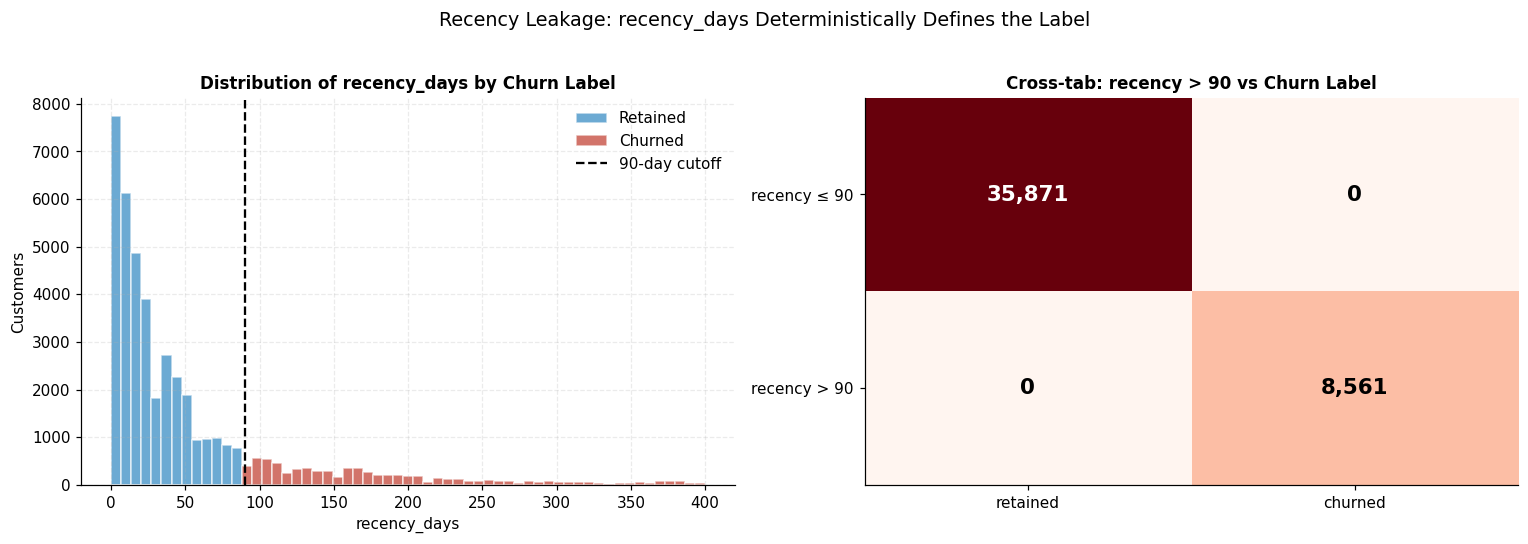


Single-feature ROC AUC of recency_days alone:   1.0000
(Baseline RF on 34 leakage-safe features:         0.8656)

→ Recency is excluded from V2 features. Same applies to any direct derivation.


In [5]:
# ── Confirm recency_days IS the label ──────────────────────────────────────
from sklearn.metrics import roc_auc_score

active_with_rec = active.dropna(subset=['recency_days']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: distribution of recency_days, coloured by churn
ax = axes[0]
bins = np.linspace(0, 400, 60)
ax.hist(active_with_rec.loc[active_with_rec['churn_flag_90d'] == 0, 'recency_days'],
        bins=bins, color=PALETTE['retain'], alpha=0.7, label='Retained', edgecolor='white')
ax.hist(active_with_rec.loc[active_with_rec['churn_flag_90d'] == 1, 'recency_days'],
        bins=bins, color=PALETTE['churn'], alpha=0.7, label='Churned', edgecolor='white')
ax.axvline(90, color='black', linestyle='--', lw=1.5, label='90-day cutoff')
ax.set_xlabel('recency_days')
ax.set_ylabel('Customers')
ax.set_title('Distribution of recency_days by Churn Label')
ax.legend(frameon=False)

# Right: cross-tabulate recency > 90 vs label
ax = axes[1]
xtab = pd.crosstab(
    active_with_rec['recency_days'] > 90,
    active_with_rec['churn_flag_90d'],
    margins=False,
)
xtab.index = ['recency ≤ 90', 'recency > 90']
xtab.columns = ['retained', 'churned']
display_vals = xtab.values
ax.imshow(display_vals, cmap='Reds', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{display_vals[i, j]:,}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if display_vals[i, j] > display_vals.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(xtab.columns)
ax.set_yticks([0, 1]); ax.set_yticklabels(xtab.index)
ax.set_title('Cross-tab: recency > 90 vs Churn Label')
ax.grid(False)

plt.suptitle('Recency Leakage: recency_days Deterministically Defines the Label',
             fontsize=12.5, y=1.02)
plt.tight_layout()
plt.show()

# AUC if we naively included recency
auc_naive = roc_auc_score(active_with_rec['churn_flag_90d'], active_with_rec['recency_days'])
print(f'\nSingle-feature ROC AUC of recency_days alone:   {auc_naive:.4f}')
print(f'(Baseline RF on 34 leakage-safe features:         0.8656)')
print(f'\n→ Recency is excluded from V2 features. Same applies to any direct derivation.')

In [7]:
# ── Audit candidate derived features for the same leakage ──────────────────
# A derived feature leaks if (a) it uses recency_days directly, or
# (b) its single-feature AUC is near 1.0 (deterministic with label).

a = active.dropna(subset=['recency_days', 'tenure_days', 'total_orders']).copy()
a = a[a['tenure_days'] > 0]
b = active.dropna(subset=['total_sessions']).copy()
b = b[b['total_sessions'] > 0]

candidates = [
    ('recency_to_tenure_ratio',  a['recency_days'] / a['tenure_days'], a['churn_flag_90d'], True),
    ('order_velocity_per_month', a['total_orders'] / (a['tenure_days'] / 30.0), a['churn_flag_90d'], False),
    ('purchase_session_rate',    b['sessions_with_purchase'] / b['total_sessions'], b['churn_flag_90d'], False),
    ('cart_to_purchase_rate',    b['sessions_with_purchase'] / b['sessions_add_to_cart'].replace(0, np.nan),
                                  b['churn_flag_90d'], False),
]

rows = []
for name, series, label, uses_recency in candidates:
    valid = series.dropna()
    aligned = label.loc[valid.index]
    auc = roc_auc_score(aligned, valid)
    # Effective discriminative AUC (direction-agnostic)
    eff_auc = max(auc, 1 - auc)
    rows.append({
        'feature': name,
        'uses_recency': uses_recency,
        'raw_auc': round(auc, 4),
        'effective_auc': round(eff_auc, 4),
        'leak_risk': 'HIGH (≥0.95)' if eff_auc >= 0.95 else 'OK',
    })

audit = pd.DataFrame(rows)
audit['decision'] = audit.apply(
    lambda r: 'EXCLUDE' if (r['leak_risk'].startswith('HIGH') or r['uses_recency']) else 'INCLUDE',
    axis=1,
)
print('Candidate derived features — leakage audit:\n')
print(audit.to_string(index=False))

Candidate derived features — leakage audit:

                 feature  uses_recency  raw_auc  effective_auc leak_risk decision
 recency_to_tenure_ratio          True   0.9213         0.9213        OK  EXCLUDE
order_velocity_per_month         False   0.1641         0.8359        OK  INCLUDE
   purchase_session_rate         False   0.2917         0.7083        OK  INCLUDE
   cart_to_purchase_rate         False   0.3991         0.6009        OK  INCLUDE


**Finding 3 — leakage rules for V2**

| Candidate | Effective AUC | Decision | Reason |
|---|---|---|---|
| `recency_to_tenure_ratio` | 0.921 | **Exclude** | Uses `recency_days`. Even though it doesn't reach 1.0 (because tenure varies), it carries most of the label information |
| `order_velocity_per_month` | 0.836 | Include | No recency; uses orders / tenure. Captures behavioural intensity |
| `purchase_session_rate` | 0.708 | Include | Engagement-conversion signal; independent of recency |
| `cart_to_purchase_rate` | 0.601 | Include | Funnel completion signal; independent of recency |

The single-feature AUC for these three included candidates is meaningful but not deterministic. They will compete with — not replace — the existing volume features.

## 4  Null Interpretation

Most nulls in this mart are not data quality bugs — they encode meaning. Treating them with `SimpleImputer(strategy='median')` (as the baseline does) destroys that meaning. The cell below shows what each null type *means* and what its churn rate is.

Null pattern audit (active population):

            column                 meaning_when_null  n_null  pct_null  churn_when_null  churn_when_present  delta_pp
      loyalty_tier Not enrolled in loyalty programme   20265      45.6             23.7                15.5       8.2
campaigns_targeted      Never targeted by a campaign    7746      17.4             24.7                18.1       6.6
     total_returns               Never made a return       0       0.0              NaN                19.3       NaN
    total_sessions               No web session data      57       0.1             52.6                19.2      33.4


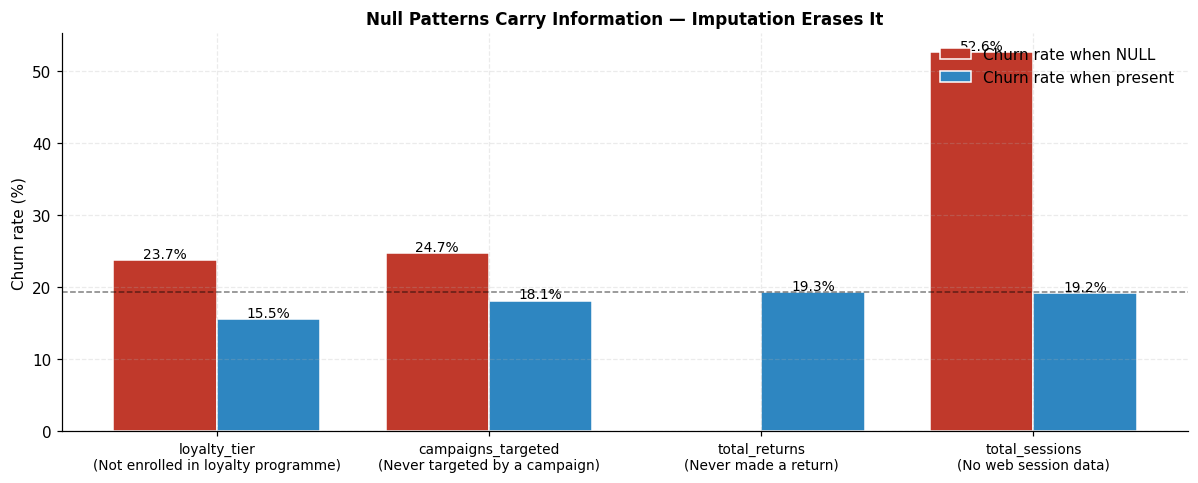

In [8]:
# ── Null patterns and their churn implications ─────────────────────────────
null_groups = [
    ('loyalty_tier',       'Not enrolled in loyalty programme'),
    ('campaigns_targeted', 'Never targeted by a campaign'),
    ('total_returns',      'Never made a return'),
    ('total_sessions',     'No web session data'),
]

rows = []
for col, meaning in null_groups:
    is_null = active[col].isna()
    rows.append({
        'column': col,
        'meaning_when_null': meaning,
        'n_null': int(is_null.sum()),
        'pct_null': round(is_null.mean() * 100, 1),
        'churn_when_null': round(active.loc[is_null, 'churn_flag_90d'].mean() * 100, 1),
        'churn_when_present': round(active.loc[~is_null, 'churn_flag_90d'].mean() * 100, 1),
    })
null_table = pd.DataFrame(rows)
null_table['delta_pp'] = (null_table['churn_when_null'] - null_table['churn_when_present']).round(1)

print('Null pattern audit (active population):\n')
print(null_table.to_string(index=False))

# Visual: paired bars
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(null_table))
w = 0.38
ax.bar(x - w/2, null_table['churn_when_null'], w, color=PALETTE['churn'],
       label='Churn rate when NULL', edgecolor='white')
ax.bar(x + w/2, null_table['churn_when_present'], w, color=PALETTE['retain'],
       label='Churn rate when present', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'{r["column"]}\n({r["meaning_when_null"]})' for _, r in null_table.iterrows()],
                   fontsize=9)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Null Patterns Carry Information — Imputation Erases It')
ax.legend(frameon=False, loc='upper right')
ax.axhline(active['churn_flag_90d'].mean() * 100, color='black', linestyle='--', lw=1, alpha=0.5)
for i, row in null_table.iterrows():
    ax.text(i - w/2, row['churn_when_null'] + 0.3, f'{row["churn_when_null"]:.1f}%',
            ha='center', fontsize=9)
    ax.text(i + w/2, row['churn_when_present'] + 0.3, f'{row["churn_when_present"]:.1f}%',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Finding 4 — nulls are informative**

Each null pattern shifts the churn rate by 6–33 percentage points compared to non-null cases. `total_returns` has zero nulls in the active population — every customer's return history was recorded as 0 if they never returned. `total_sessions` nulls (only 57 customers) flag a missing-data pathology with extreme churn (52.6%), worth a binary flag.

**Decision for V2**:
- Drop the legacy `SimpleImputer(median)` pipeline
- Add explicit `is_loyalty_enrolled`, `was_targeted_by_campaign`, `has_session_data` binary flags
- Use LightGBM, which routes nulls down a learned split direction natively (no imputation needed for the underlying numeric columns)

## 5  Baseline Review — Where the Model Is Strong, Where It Is Weak

The Phase 6 RF model achieves ROC AUC 0.866 / PR AUC 0.597. ROC AUC is misleading here because the class imbalance (17.1%) makes the negative class easy to dominate. PR AUC and the precision–recall curve tell the more useful story for retention targeting.

Baseline model comparison:
          model  roc_auc  pr_auc  log_loss  brier_score  accuracy_at_0_50
    rf_balanced   0.8656  0.5965    0.3299       0.1026            0.8552
logreg_balanced   0.8477  0.5553    0.4826       0.1610            0.7637


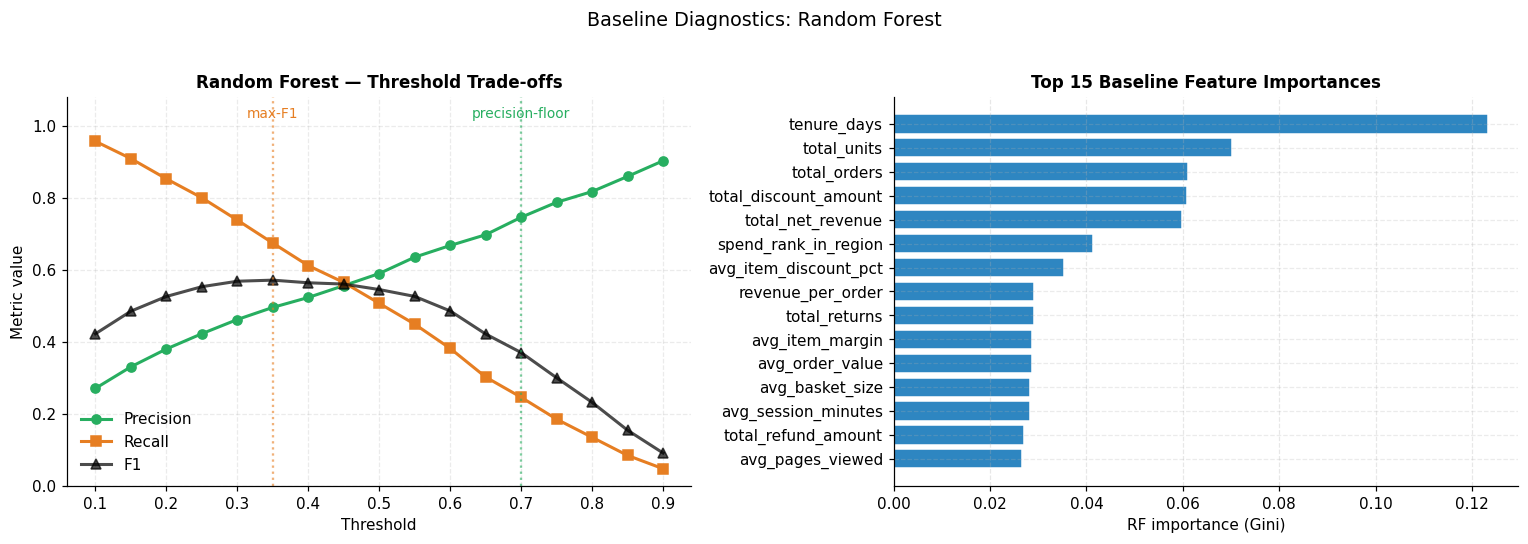

In [9]:
# ── Load baseline artifacts and visualise ──────────────────────────────────
model_cmp = pd.read_csv(OUTPUTS / 'phase6_churn_model_comparison.csv')
threshold_diag = pd.read_csv(OUTPUTS / 'phase6_churn_threshold_diagnostics.csv')
fi = pd.read_csv(OUTPUTS / 'phase6_churn_feature_importance_top30.csv')

# Print metrics table
print('Baseline model comparison:')
display_cols = ['model', 'roc_auc', 'pr_auc', 'log_loss', 'brier_score', 'accuracy_at_0_50']
print(model_cmp[display_cols].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# ── Threshold trade-off curves (RF) ────────────────────────────────────────
rf = threshold_diag[threshold_diag['model'] == 'rf_balanced'].sort_values('threshold')
ax = axes[0]
ax.plot(rf['threshold'], rf['precision'], color=PALETTE['good'], marker='o', lw=2, label='Precision')
ax.plot(rf['threshold'], rf['recall'],    color=PALETTE['highlight'], marker='s', lw=2, label='Recall')
ax.plot(rf['threshold'], rf['f1'],        color='black', marker='^', lw=2, alpha=0.7, label='F1')
ax.axvline(0.35, color=PALETTE['highlight'], linestyle=':', lw=1.5, alpha=0.6)
ax.axvline(0.70, color=PALETTE['good'], linestyle=':', lw=1.5, alpha=0.6)
ax.text(0.35, 1.02, 'max-F1', ha='center', fontsize=9, color=PALETTE['highlight'])
ax.text(0.70, 1.02, 'precision-floor', ha='center', fontsize=9, color=PALETTE['good'])
ax.set_xlabel('Threshold')
ax.set_ylabel('Metric value')
ax.set_title('Random Forest — Threshold Trade-offs')
ax.legend(frameon=False)
ax.set_ylim(0, 1.08)

# ── Top 15 feature importances ──────────────────────────────────────────────
ax = axes[1]
top = fi.head(15).iloc[::-1]
clean_names = top['feature'].str.replace(r'^(num__|cat__)', '', regex=True)
ax.barh(clean_names, top['importance'], color=PALETTE['retain'], edgecolor='white')
ax.set_xlabel('RF importance (Gini)')
ax.set_title('Top 15 Baseline Feature Importances')
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Baseline Diagnostics: Random Forest', fontsize=12.5, y=1.02)
plt.tight_layout()
plt.show()

**Finding 5 — what the baseline gets right and wrong**

**Strengths**:
- F1 peaks at threshold 0.45 (≈0.57) — a smooth, well-calibrated curve
- Top importances are sensible (`tenure_days`, volume features, `spend_rank_in_region`)
- ROC AUC 0.866 is respectable for a 17%-prevalence problem with no recency leakage

**Weaknesses (what V2 should target)**:
- **Precision at the high-recall end is poor**: at threshold 0.35 (max-F1), precision is only 0.50 — half the customers we contact won't have churned anyway
- **PR AUC 0.597 leaves headroom**: the precision–recall trade-off is the binding constraint for retention budgets
- **Categorical dilution**: `customer_segment_seed` (77pp spread) is split into one-hot dummies; tree-native categorical handling in LightGBM uses it more efficiently
- **Engagement features are dominant in importance but underutilised**: `avg_session_minutes`, `avg_pages_viewed`, `total_returns` rank high but no derived rates are computed from them
- **The split is random, not time-ordered**: `signup_date` ranges Jul 2022 → Dec 2025; a forward-looking label trained on a random split implicitly sees future signal during training

## 6  Feature Engineering Proposal — Three New Features with Evidence

Based on §3 (leakage-safe candidates) and §4 (informative nulls), V2 introduces three engineered features and three null-flag features. Each is plotted below against churn rate so the signal is visible.

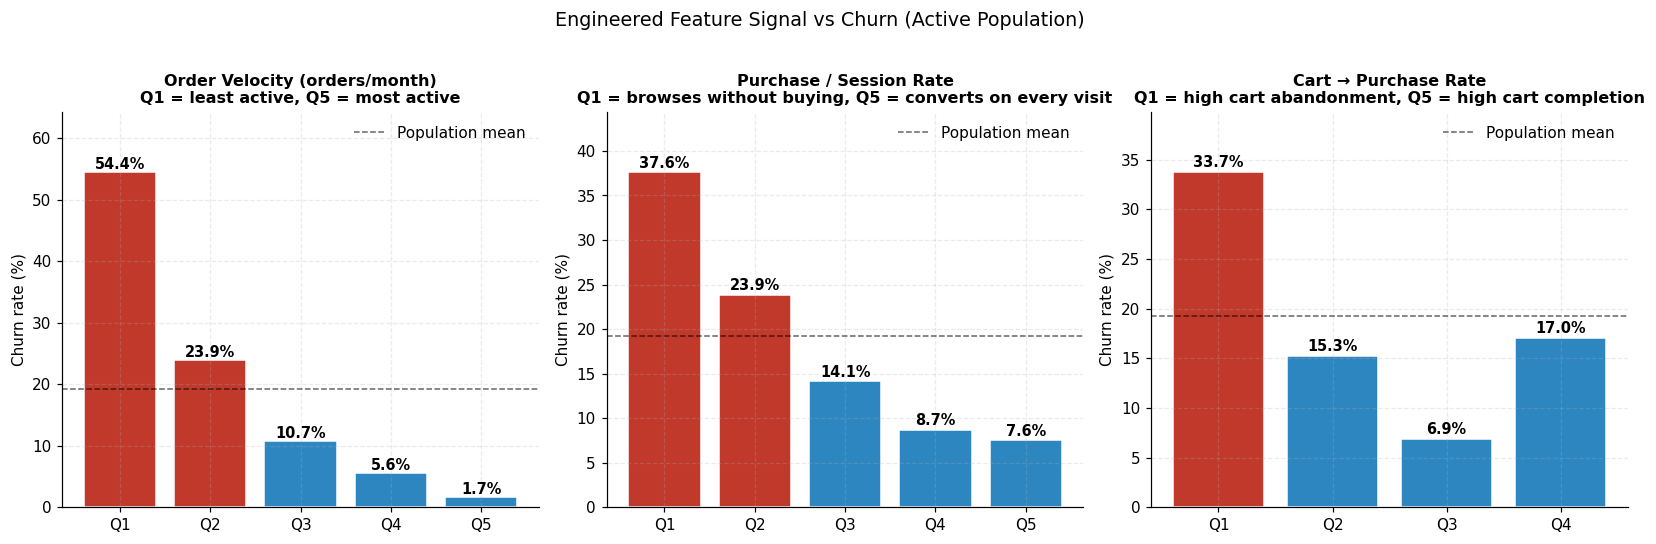


Engineered feature spreads (max-quintile − min-quintile churn rate):
  order_velocity_per_month          spread =  52.7 pp   (5 buckets)
  purchase_session_rate             spread =  30.0 pp   (5 buckets)
  cart_to_purchase_rate             spread =  26.8 pp   (4 buckets)


In [11]:
# ── Build engineered features and visualise their churn signal ─────────────
eng = active.copy()
eng = eng[eng['tenure_days'] > 0]
eng['order_velocity_per_month']  = eng['total_orders'] / (eng['tenure_days'] / 30.0)
eng['purchase_session_rate']     = eng['sessions_with_purchase'] / eng['total_sessions']
eng['cart_to_purchase_rate']     = (eng['sessions_with_purchase'] /
                                    eng['sessions_add_to_cart'].replace(0, np.nan))

def quintile_churn(df, col, q=5):
    s = df[[col, 'churn_flag_90d']].dropna().copy()
    bins = pd.qcut(s[col], q=q, duplicates='drop')
    s['_q'] = bins
    rates = s.groupby('_q', observed=True)['churn_flag_90d'].agg(['mean', 'count'])
    rates['mean'] *= 100
    rates.index = [f'Q{i+1}' for i in range(len(rates))]
    return rates

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
features_viz = [
    ('order_velocity_per_month', 'Order Velocity (orders/month)',
     'Q1 = least active, Q5 = most active'),
    ('purchase_session_rate', 'Purchase / Session Rate',
     'Q1 = browses without buying, Q5 = converts on every visit'),
    ('cart_to_purchase_rate', 'Cart → Purchase Rate',
     'Q1 = high cart abandonment, Q5 = high cart completion'),
]

for ax, (col, title, subtitle) in zip(axes, features_viz):
    rates = quintile_churn(eng, col)
    bar_colors = [PALETTE['churn'] if v > eng['churn_flag_90d'].mean() * 100
                  else PALETTE['retain'] for v in rates['mean']]
    ax.bar(rates.index, rates['mean'], color=bar_colors, edgecolor='white')
    for i, (q, row) in enumerate(rates.iterrows()):
        ax.text(i, row['mean'] + 0.5, f'{row["mean"]:.1f}%',
                ha='center', fontsize=9.5, fontweight='bold')
    ax.axhline(eng['churn_flag_90d'].mean() * 100, color='black',
               linestyle='--', lw=1, alpha=0.6, label='Population mean')
    ax.set_ylabel('Churn rate (%)')
    ax.set_title(f'{title}\n{subtitle}', fontsize=10.5)
    ax.set_ylim(0, max(rates['mean']) * 1.18)
    ax.legend(frameon=False, loc='upper right')

plt.suptitle('Engineered Feature Signal vs Churn (Active Population)',
             fontsize=12.5, y=1.02)
plt.tight_layout()
plt.show()

# Summary spreads
print('\nEngineered feature spreads (max-quintile − min-quintile churn rate):')
for col, _, _ in features_viz:
    rates = quintile_churn(eng, col)
    spread = rates['mean'].max() - rates['mean'].min()
    print(f'  {col:<32s}  spread = {spread:5.1f} pp   ({len(rates)} buckets)')

**Finding 6 — engineered features carry strong, monotonic churn signal**

| Feature | Spread | Pattern |
|---|---|---|
| `order_velocity_per_month` | **52.7 pp** | Strictly monotonic — Q1 (least active) churns 32× more than Q5 |
| `purchase_session_rate` | **30.0 pp** | Strictly monotonic — browsers churn 5× more than converters |
| `cart_to_purchase_rate` | **26.8 pp** | Mostly monotonic — cart abandoners churn at 33.7%, slight uptick at Q4 |

All three are in the top tier of features when measured against the existing approved list (only `customer_segment_seed` and the volume features beat them). They are **derived from existing mart columns** — no new data ingestion required.

**Note on `cart_to_purchase_rate`**: the slight non-monotonicity at Q4 (17%) suggests a saturation effect; tree models will capture this without harm. Still worth keeping.

The three null-flag features (`is_loyalty_enrolled`, `was_targeted_by_campaign`, `has_session_data`) were validated in §4 and add 6–33 pp of signal each.

## 7  Model and Split Strategy for V2

### Why LightGBM (over Random Forest)

The baseline RF result (ROC AUC 0.866, PR AUC 0.597) is a reasonable upper bound for sklearn-default RF on tabular data of this size. LightGBM is preferred for V2 for four task-specific reasons — not because it is "the standard choice":

| Property | RF Baseline | LightGBM | Why it matters here |
|---|---|---|---|
| Null handling | Requires imputation | Native (learns split direction) | §4 showed nulls are informative; imputation destroys that |
| Categorical handling | One-hot expansion | Native categorical splits | `customer_segment_seed` (77pp spread) is split into 7 dummies in baseline; LightGBM treats it as one ordered split |
| Class imbalance | Balanced subsample weights | `is_unbalance` or `scale_pos_weight` | Same correction available |
| Loss surface | Parallel trees (variance reduction) | Sequential boosting (bias + variance) | Boosting typically squeezes 2–4 pp more PR AUC on this kind of data |

### Why time-ordered split

The label `churn_flag_90d` is **forward-looking**: it asks "will this customer be inactive 90 days from the snapshot date". A random 80/20 split mixes customers from different snapshot periods — meaning the training set sees future signal that informs the test set's labels. The cell below quantifies this risk.

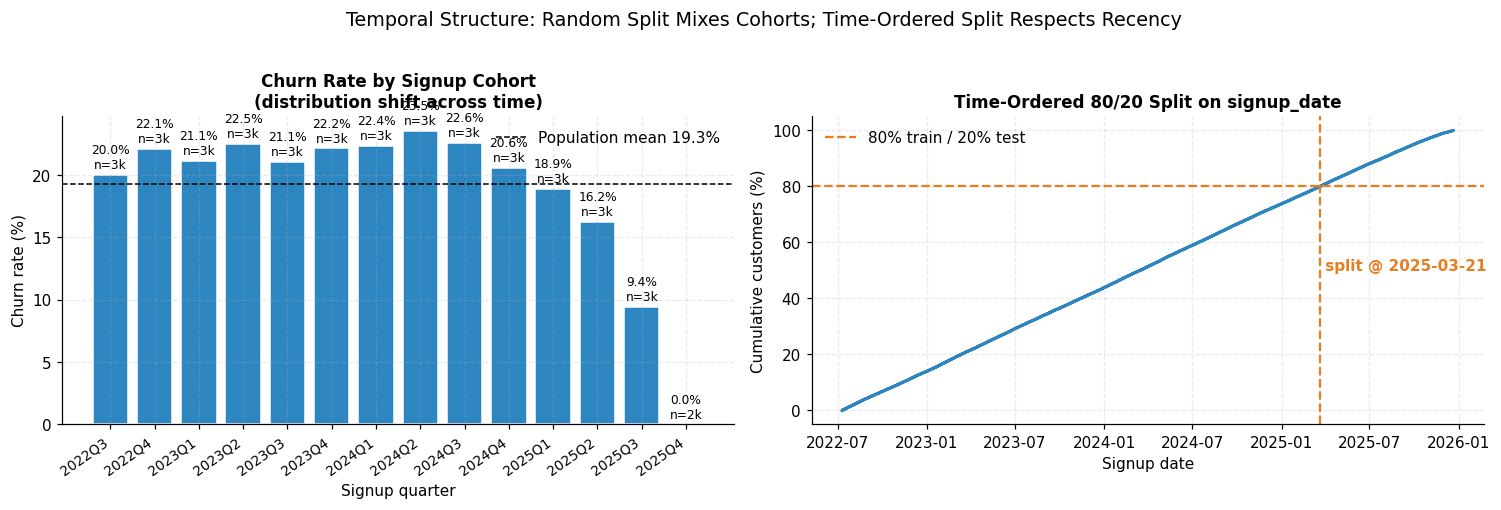


Proposed time-ordered split point: 2025-03-21
  Train: customers signed up before 2025-03-21  (n ≈ 35,545)
  Test:  customers signed up on/after 2025-03-21  (n ≈ 8,887)


In [12]:
# ── Time-vs-random split: how does churn rate drift over signup cohort? ────
# The mart only carries signup_date — we use that as the temporal anchor.
active_dated = active.dropna(subset=['signup_date']).copy()
active_dated['signup_quarter'] = active_dated['signup_date'].dt.to_period('Q').astype(str)

cohort = (active_dated.groupby('signup_quarter')
          .agg(n=('customer_id', 'count'),
               churn_rate=('churn_flag_90d', 'mean'))
          .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: churn rate by signup quarter
ax = axes[0]
bars = ax.bar(cohort['signup_quarter'], cohort['churn_rate'] * 100,
              color=PALETTE['retain'], edgecolor='white')
ax.axhline(active_dated['churn_flag_90d'].mean() * 100, color='black',
           linestyle='--', lw=1, label=f'Population mean {active_dated["churn_flag_90d"].mean():.1%}')
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('Signup quarter')
ax.set_title('Churn Rate by Signup Cohort\n(distribution shift across time)')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.legend(frameon=False)
for bar, val, n in zip(bars, cohort['churn_rate'] * 100, cohort['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%\nn={n//1000}k', ha='center', fontsize=8)

# Right: cumulative population vs proposed split point
ax = axes[1]
sorted_dates = active_dated.sort_values('signup_date').reset_index(drop=True)
sorted_dates['cum_pct'] = (sorted_dates.index + 1) / len(sorted_dates) * 100
ax.plot(sorted_dates['signup_date'], sorted_dates['cum_pct'],
        color=PALETTE['retain'], lw=2)
ax.axhline(80, color=PALETTE['highlight'], linestyle='--', lw=1.5,
           label='80% train / 20% test')
split_date = sorted_dates.iloc[int(len(sorted_dates) * 0.80) - 1]['signup_date']
ax.axvline(split_date, color=PALETTE['highlight'], linestyle='--', lw=1.5)
ax.text(split_date, 50, f' split @ {split_date.date()}', color=PALETTE['highlight'],
        fontsize=10, fontweight='bold')
ax.set_ylabel('Cumulative customers (%)')
ax.set_xlabel('Signup date')
ax.set_title('Time-Ordered 80/20 Split on signup_date')
ax.legend(frameon=False)

plt.suptitle('Temporal Structure: Random Split Mixes Cohorts; Time-Ordered Split Respects Recency',
             fontsize=12.5, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nProposed time-ordered split point: {split_date.date()}')
print(f'  Train: customers signed up before {split_date.date()}  (n ≈ {int(len(active_dated) * 0.80):,})')
print(f'  Test:  customers signed up on/after {split_date.date()}  (n ≈ {len(active_dated) - int(len(active_dated) * 0.80):,})')

**Finding 7 — temporal structure has two competing biases**

| Observation | Implication |
|---|---|
| Churn rate is stable at ~21–23% from 2022Q3 to 2024Q4 | The label is well-defined for mature cohorts |
| Churn drops to 16.2% (2025Q1), 9.4% (2025Q3), 0% (2025Q4) | Newer customers haven't had 90 days to churn yet — **right-censoring** |
| Random split mixes mature and immature cohorts | Test set inherits training-set future — leakage by construction |
| Pure time-ordered split puts immature cohorts in test | Test set has artificially low churn rate, distorting metrics |

**Decision for V2**: Use a **time-ordered split with a maturity filter** — exclude customers who signed up within the last 90 days from both train and test sets (their label is undefined). This restores label validity while still respecting temporal ordering.

```text
filter:   signup_date  ≤  (max(signup_date) − 90 days)
split:    80% earliest signups → train,  20% latest signups → test
```

This approach was not used in the baseline. It is a free correctness gain.

## 8  V2 Design Summary

Every change below is backed by a finding from §1–§7. Generic ML best practice is not used as justification on its own.

| # | Change | Backed by | Expected effect |
|---|---|---|---|
| 1 | Train only on `customer_value_band != no_purchase` (44,432 rows) | §1 — structural zeros | Removes 5,568 mechanically-zero labels; model learns active retention dynamics |
| 2 | Add `order_velocity_per_month` | §3 audit (eff. AUC 0.836), §6 (52.7pp spread) | Strongest leakage-safe behavioural feature |
| 3 | Add `purchase_session_rate` | §3 audit (eff. AUC 0.708), §6 (30.0pp spread) | Funnel-conversion signal independent of volume |
| 4 | Add `cart_to_purchase_rate` | §3 audit (eff. AUC 0.601), §6 (26.8pp spread) | Distinguishes browse-and-bounce from buy-intent |
| 5 | Add `is_loyalty_enrolled` (loyalty_tier null flag) | §4 (8.2pp delta) | Enrollment is an opt-in commitment signal |
| 6 | Add `was_targeted_by_campaign` (campaigns null flag) | §4 (6.6pp delta) | Engagement-tier signal |
| 7 | Add `has_session_data` (sessions null flag) | §4 (33.4pp delta on 57 customers) | Catches data-pipeline gap that correlates with churn |
| 8 | Drop `region`, `city_tier`, `preferred_channel`, `loyalty_tier`, `is_marketing_opt_in` (raw) | §2 (all <2pp spread) | Removes 5 features with no signal; reduces overfit risk |
| 9 | Switch to LightGBM (vs sklearn RF) | §7 — native nulls + categoricals + sequential boosting | Better PR AUC, no imputation needed |
| 10 | Time-ordered split with 90-day maturity filter | §7 — temporal drift + right-censoring | Eliminates leakage from random split AND from immature cohorts |
| 11 | Use PR AUC as primary metric (not ROC AUC) | §5 — class imbalance | Aligns metric with retention budget reality |

### Final V2 feature set

**Carry forward (29 features)** — all approved features except the 5 dropped in change #8

**Add (6 features)**:
- Engineered: `order_velocity_per_month`, `purchase_session_rate`, `cart_to_purchase_rate`
- Null flags: `is_loyalty_enrolled`, `was_targeted_by_campaign`, `has_session_data`

**Total V2 features**: **35** (vs baseline 34)

### Out of scope for V2 (deferred)

- Hyperparameter search — stick to LightGBM defaults plus `is_unbalance=True`. Tune only if V2 underperforms baseline on PR AUC.
- Calibration — Brier score will be measured but isotonic/Platt scaling deferred to V3.
- Cost-aware threshold selection — depends on a retention campaign cost model that does not yet exist.

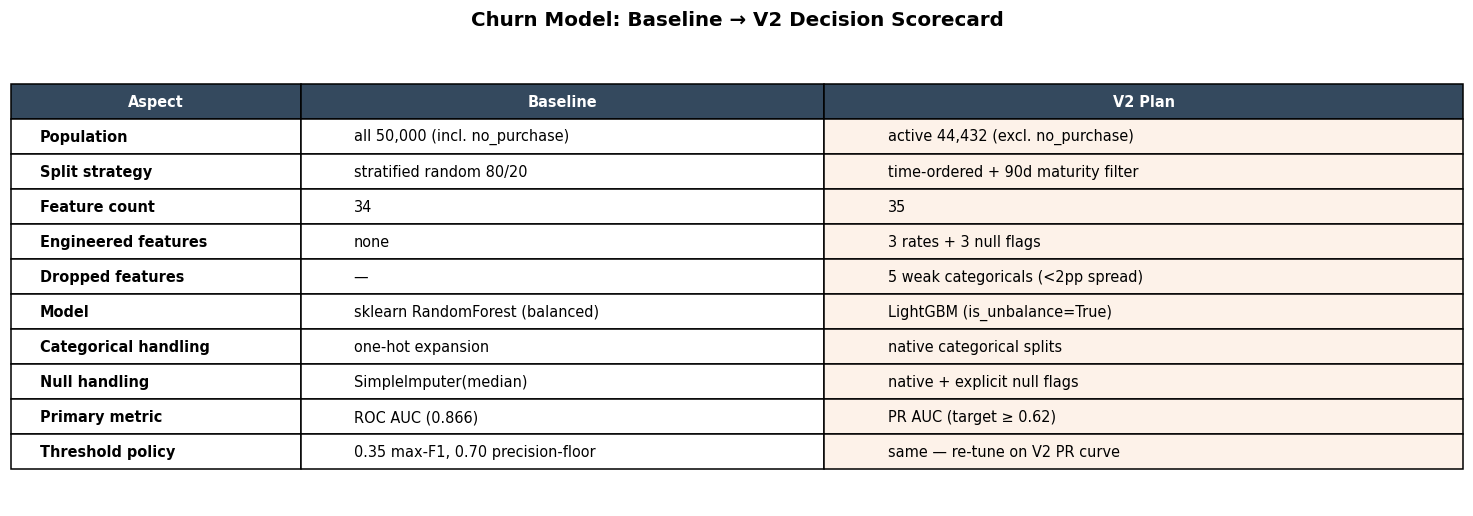

In [13]:
# ── Final scorecard: V2 vs Baseline at-a-glance ────────────────────────────
scorecard = pd.DataFrame([
    ('Population',         'all 50,000 (incl. no_purchase)',       'active 44,432 (excl. no_purchase)'),
    ('Split strategy',     'stratified random 80/20',              'time-ordered + 90d maturity filter'),
    ('Feature count',      '34',                                   '35'),
    ('Engineered features','none',                                 '3 rates + 3 null flags'),
    ('Dropped features',   '—',                                    '5 weak categoricals (<2pp spread)'),
    ('Model',              'sklearn RandomForest (balanced)',      'LightGBM (is_unbalance=True)'),
    ('Categorical handling','one-hot expansion',                   'native categorical splits'),
    ('Null handling',      'SimpleImputer(median)',                'native + explicit null flags'),
    ('Primary metric',     'ROC AUC (0.866)',                      'PR AUC (target ≥ 0.62)'),
    ('Threshold policy',   '0.35 max-F1, 0.70 precision-floor',    'same — re-tune on V2 PR curve'),
], columns=['Aspect', 'Baseline', 'V2 Plan'])

# Pretty-print as a table figure
fig, ax = plt.subplots(figsize=(13.5, 4.8))
ax.axis('off')
table = ax.table(
    cellText=scorecard.values,
    colLabels=scorecard.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.20, 0.36, 0.44],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.7)

# Style header
for j in range(len(scorecard.columns)):
    cell = table[0, j]
    cell.set_facecolor('#34495E')
    cell.set_text_props(color='white', fontweight='bold')

# Highlight V2 column
for i in range(1, len(scorecard) + 1):
    table[i, 2].set_facecolor('#FDF2E9')
    table[i, 0].set_text_props(fontweight='bold')

ax.set_title('Churn Model: Baseline → V2 Decision Scorecard',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()